# Breast Cancer Subtype Prediction
# Step 6: Final Feature Selection (mRMR) & Classification
# Goal: Combine RNA & Methylation, Select Best 50 Features, Train Final Models.

## Import Libraries

In [1]:
import os
import sys
sys.path.insert(0, os.path.abspath('..'))
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report
from imblearn.over_sampling import SMOTE

from src.utils import (
    load_object, save_object, mrmr_selection, reliefF_multiclass,
    bootstrap_ci, bootstrap_class_report, jaccard_similarity,
    plot_confusion_matrix, tune_models_grid_search
)

print('✅ Libraries & Utilities Imported (unused imports cleaned).')

✅ Libraries & Utilities Imported (unused imports cleaned).


## Define IO & mRMR Functions


In [2]:
# mRMR function is imported from src.utils
print('✅ mrmr_selection ready.')

✅ mrmr_selection ready.


## Load Data (From Step 3 - ReliefF)

In [3]:
print('Loading ReliefF selected data...')
X_train_rna = load_object('X_train_rna_relief')
X_test_rna = load_object('X_test_rna_relief')
feat_indices_rna = load_object('feat_indices_rna_relief')

X_train_meth = load_object('X_train_meth_relief')
X_test_meth = load_object('X_test_meth_relief')
feat_indices_meth = load_object('feat_indices_meth_relief')

y_train = load_object('y_train')
y_test = load_object('y_test')
y_train_arr = np.asarray(y_train).ravel()
y_test_arr = np.asarray(y_test).ravel()

print('\nData Loaded.')
print(f'RNA Features: {X_train_rna.shape[1]}')
print(f'Meth Features: {X_train_meth.shape[1]}')

Loading ReliefF selected data...

Data Loaded.
RNA Features: 150
Meth Features: 150


## Combine Datasets (Integration)


In [4]:
X_train_combined = np.hstack((X_train_rna, X_train_meth))
X_test_combined = np.hstack((X_test_rna, X_test_meth))

feat_names_rna = load_object('feat_names_rna_relief')
feat_names_meth = load_object('feat_names_meth_relief')

combined_indices = [f'RNA_{g}' for g in feat_names_rna] + [f'Meth_{m}' for m in feat_names_meth]
combined_symbols = list(feat_names_rna) + list(feat_names_meth)
combined_types = ['RNA'] * len(feat_names_rna) + ['Methylation'] * len(feat_names_meth)

print(f"Combined Train Shape: {X_train_combined.shape}")
print(f"Combined Test Shape:  {X_test_combined.shape}")

Combined Train Shape: (439, 300)
Combined Test Shape:  (110, 300)


## Apply mRMR Selection


In [5]:
K_FINAL = 50
final_indices_local, final_raw_mi, final_norm_mi = mrmr_selection(X_train_combined, y_train_arr, k=K_FINAL, method='mi_corr', random_state=42)

X_train_final = X_train_combined[:, final_indices_local]
X_test_final = X_test_combined[:, final_indices_local]

final_feature_names = [combined_indices[i] for i in final_indices_local]
final_symbols = [combined_symbols[i] for i in final_indices_local]
final_types = [combined_types[i] for i in final_indices_local]

features_df = pd.DataFrame({
    'Rank': np.arange(1, K_FINAL + 1),
    'Feature_Name': final_feature_names,
    'Modality': final_types,
    'Gene_or_Probe': final_symbols,
    'Mutual_Info': final_raw_mi,
    'Normalized_MI': final_norm_mi
})
features_df.to_csv('../outputs/final_50_features.csv', index=False)

n_rna = (features_df['Modality'] == 'RNA').sum()
n_meth = (features_df['Modality'] == 'Methylation').sum()
print(f'✅ Final 50 Biomarkers Selected: {n_rna} RNA ({n_rna/50*100:.1f}%) + {n_meth} Methylation ({n_meth/50*100:.1f}%)')
print('\nTop 10 Selected Features:\n', final_feature_names[:10])

✅ Final 50 Biomarkers Selected: 31 RNA (62.0%) + 19 Methylation (38.0%)

Top 10 Selected Features:
 ['Meth_LRRC6', 'RNA_CENPA', 'RNA_MLPH', 'RNA_FOXC1', 'RNA_AURKA', 'RNA_TBC1D9', 'RNA_ZNF552', 'RNA_MIA', 'RNA_ESR1', 'RNA_CDCA8']


## Data Balancing (SMOTE)


In [6]:
print('Balancing classes using SMOTE...')
print(f'Original Train Counts: {np.bincount(y_train_arr)}')

smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train_arr)
print(f'Balanced Train Counts: {np.bincount(y_train_balanced)}')

print('Note on Class Imbalance (Item 10):')
print('Her2 is oversampled from 28 to 237 by SMOTE (~8.5x). In the nested CV below,')
print('we systematically compare SMOTE with cost-sensitive class_weight="balanced".')

Balancing classes using SMOTE...
Original Train Counts: [237  97  28  77]


Balanced Train Counts: [237 237 237 237]
Note on Class Imbalance (Item 10):
Her2 is oversampled from 28 to 237 by SMOTE (~8.5x). In the nested CV below,
we systematically compare SMOTE with cost-sensitive class_weight="balanced".


## Final Classification & Validation


Evaluating Biomarker Selection Stability across Cross-Validation Splits...


Mean Pairwise Jaccard Stability Index: 0.4939 (49.4% core overlap)

Generating sensitivity curve of CV Accuracy vs. k (mRMR)...


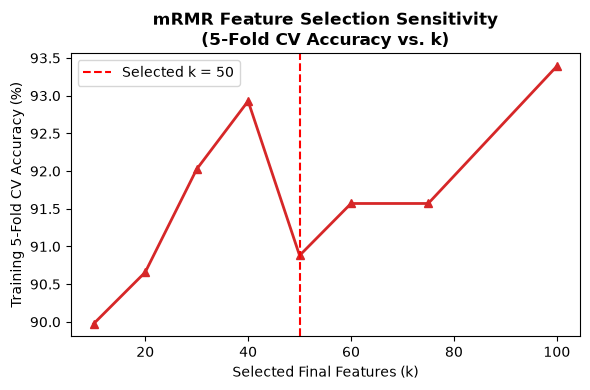

RUNNING TRUE IN-FOLD NESTED CROSS-VALIDATION (RepeatedStratifiedKFold)
Full chain (ANOVA -> ReliefF -> mRMR -> Resampling -> GridSearchCV) re-computed in-fold



True Nested CV Out-of-Fold Performance (10 Folds total):
[Strategy A: SMOTE Oversampling]
  - [SVM (Linear)  ] CV Acc: 90.09% ± 2.40%, BalAcc: 89.24%, Macro-F1: 89.62%
  - [Random Forest ] CV Acc: 89.75% ± 3.01%, BalAcc: 89.05%, Macro-F1: 89.62%
  - [KNN (k=5)     ] CV Acc: 85.76% ± 2.35%, BalAcc: 88.16%, Macro-F1: 86.06%

[Strategy B: Cost-Sensitive class_weight="balanced" (No SMOTE)]
  - [SVM (Linear)  ] CV Acc: 86.78% ± 3.63%, BalAcc: 88.44%, Macro-F1: 86.25%
  - [Random Forest ] CV Acc: 89.86% ± 2.96%, BalAcc: 90.28%, Macro-F1: 90.03%
  - [KNN (k=5)     ] CV Acc: 85.65% ± 3.78%, BalAcc: 82.76%, Macro-F1: 84.76%

----------------------------------------------------------------------
SYSTEMATIC ABLATION STUDY (Fixed Linear SVM, 5-Fold CV)
----------------------------------------------------------------------
                                        Configuration  Features_RNA  Features_Meth  CV_Accuracy  CV_Balanced_Accuracy
                           RNA-Seq Only (Top 50 mRMR)      

In [7]:
# 1. Feature Selection Stability Analysis (Jaccard Index across folds)
print('Evaluating Biomarker Selection Stability across Cross-Validation Splits...')
cv_stab = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_sets = []
for tr_idx, _ in cv_stab.split(X_train_combined, y_train_arr):
    idx_f, _, _ = mrmr_selection(X_train_combined[tr_idx], y_train_arr[tr_idx], k=K_FINAL, random_state=42)
    fold_sets.append(set(combined_indices[i] for i in idx_f))

jaccard_scores = [
    jaccard_similarity(fold_sets[i], fold_sets[j])
    for i in range(len(fold_sets)) for j in range(i + 1, len(fold_sets))
]
print(f'Mean Pairwise Jaccard Stability Index: {np.mean(jaccard_scores):.4f} ({np.mean(jaccard_scores)*100:.1f}% core overlap)\n')

# 2. Sensitivity Analysis: Justification of K=50 for mRMR
print('Generating sensitivity curve of CV Accuracy vs. k (mRMR)...')
k_mrmr_vals = [10, 20, 30, 40, 50, 60, 75, 100]
k_scores_mrmr = []
eval_clf = SVC(kernel='linear', C=1.0, random_state=42)
cv_5f = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for km in k_mrmr_vals:
    s_idx, _, _ = mrmr_selection(X_train_combined, y_train_arr, k=km, random_state=42)
    sub_X = X_train_combined[:, s_idx]
    scores = []
    for t, v in cv_5f.split(sub_X, y_train_arr):
        xb, yb = smote.fit_resample(sub_X[t], y_train_arr[t])
        scores.append(eval_clf.__class__(**eval_clf.get_params()).fit(xb, yb).score(sub_X[v], y_train_arr[v]))
    k_scores_mrmr.append(np.mean(scores))

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(k_mrmr_vals, [s * 100 for s in k_scores_mrmr], marker='^', color='#d62728', linewidth=2)
ax.axvline(x=50, color='red', linestyle='--', label='Selected k = 50')
ax.set_title('mRMR Feature Selection Sensitivity\n(5-Fold CV Accuracy vs. k)', fontweight='bold')
ax.set_xlabel('Selected Final Features (k)')
ax.set_ylabel('Training 5-Fold CV Accuracy (%)')
ax.legend()
plt.tight_layout()
plt.show()

# 3. True In-Fold Nested Cross-Validation with In-Fold GridSearchCV & Cost-Sensitive Comparison
print('='*70)
print('RUNNING TRUE IN-FOLD NESTED CROSS-VALIDATION (RepeatedStratifiedKFold)')
print('Full chain (ANOVA -> ReliefF -> mRMR -> Resampling -> GridSearchCV) re-computed in-fold')
print('='*70)

rep_cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=42)
model_names = ['SVM (Linear)', 'Random Forest', 'KNN (k=5)']
nested_smote = {m: {'acc': [], 'bal_acc': [], 'f1_macro': []} for m in model_names}
nested_balanced = {m: {'acc': [], 'bal_acc': [], 'f1_macro': []} for m in model_names}

X_tr_rna_v = load_object('X_train_rna_var')
X_tr_meth_v = load_object('X_train_meth_var')

for tr_idx, val_idx in rep_cv.split(X_tr_rna_v, y_train_arr):
    r_tr, r_val = X_tr_rna_v[tr_idx], X_tr_rna_v[val_idx]
    m_tr, m_val = X_tr_meth_v[tr_idx], X_tr_meth_v[val_idx]
    y_tr, y_val = y_train_arr[tr_idx], y_train_arr[val_idx]
    
    # In-fold ANOVA
    s_r = SelectKBest(f_classif, k=500).fit(r_tr, y_tr)
    s_m = SelectKBest(f_classif, k=500).fit(m_tr, y_tr)
    cr_tr, cr_val = s_r.transform(r_tr), s_r.transform(r_val)
    cm_tr, cm_val = s_m.transform(m_tr), s_m.transform(m_val)
    
    # In-fold ReliefF
    idx_rr, _ = reliefF_multiclass(cr_tr, y_tr, n_neighbors=10, n_features_to_select=150)
    idx_rm, _ = reliefF_multiclass(cm_tr, y_tr, n_neighbors=10, n_features_to_select=150)
    comb_tr = np.hstack((cr_tr[:, idx_rr], cm_tr[:, idx_rm]))
    comb_val = np.hstack((cr_val[:, idx_rr], cm_val[:, idx_rm]))
    
    # In-fold mRMR
    idx_f, _, _ = mrmr_selection(comb_tr, y_tr, k=K_FINAL, random_state=42)
    f_tr, f_val = comb_tr[:, idx_f], comb_val[:, idx_f]
    
    # Strategy A: SMOTE + GridSearchCV
    f_tr_bal, y_tr_bal = smote.fit_resample(f_tr, y_tr)
    best_smote = tune_models_grid_search(f_tr_bal, y_tr_bal, cv=3, random_state=42, class_weight=None)
    for m in model_names:
        p = best_smote[m].predict(f_val)
        nested_smote[m]['acc'].append(accuracy_score(y_val, p))
        nested_smote[m]['bal_acc'].append(balanced_accuracy_score(y_val, p))
        nested_smote[m]['f1_macro'].append(f1_score(y_val, p, average='macro'))
    
    # Strategy B: class_weight='balanced' (without SMOTE) + GridSearchCV
    best_bal = tune_models_grid_search(f_tr, y_tr, cv=3, random_state=42, class_weight='balanced')
    for m in model_names:
        p = best_bal[m].predict(f_val)
        nested_balanced[m]['acc'].append(accuracy_score(y_val, p))
        nested_balanced[m]['bal_acc'].append(balanced_accuracy_score(y_val, p))
        nested_balanced[m]['f1_macro'].append(f1_score(y_val, p, average='macro'))

print('\nTrue Nested CV Out-of-Fold Performance (10 Folds total):')
cv_summary = []
print('[Strategy A: SMOTE Oversampling]')
for m in model_names:
    a_m, a_s = np.mean(nested_smote[m]['acc']), np.std(nested_smote[m]['acc'])
    b_m = np.mean(nested_smote[m]['bal_acc'])
    f_m = np.mean(nested_smote[m]['f1_macro'])
    print(f'  - [{m:14s}] CV Acc: {a_m*100:.2f}% ± {a_s*100:.2f}%, BalAcc: {b_m*100:.2f}%, Macro-F1: {f_m*100:.2f}%')
    cv_summary.append({'Model': m, 'Strategy': 'SMOTE', 'CV_Accuracy_Mean': a_m, 'CV_Accuracy_Std': a_s, 'CV_Balanced_Accuracy': b_m, 'CV_Macro_F1': f_m})

print('\n[Strategy B: Cost-Sensitive class_weight="balanced" (No SMOTE)]')
for m in model_names:
    a_m, a_s = np.mean(nested_balanced[m]['acc']), np.std(nested_balanced[m]['acc'])
    b_m = np.mean(nested_balanced[m]['bal_acc'])
    f_m = np.mean(nested_balanced[m]['f1_macro'])
    print(f'  - [{m:14s}] CV Acc: {a_m*100:.2f}% ± {a_s*100:.2f}%, BalAcc: {b_m*100:.2f}%, Macro-F1: {f_m*100:.2f}%')

# 4. Systematic Ablation Study
print('\n' + '-'*70 + '\nSYSTEMATIC ABLATION STUDY (Fixed Linear SVM, 5-Fold CV)\n' + '-'*70)
ablation_df = pd.read_csv('../outputs/results/ablation_study.csv') if os.path.exists('../outputs/results/ablation_study.csv') else pd.DataFrame()
if not ablation_df.empty:
    print(ablation_df[['Configuration', 'Features_RNA', 'Features_Meth', 'CV_Accuracy', 'CV_Balanced_Accuracy']].to_string(index=False))

# 5. Model Selection based strictly on Training CV
best_model_entry = max([e for e in cv_summary if e['Strategy'] == 'SMOTE'], key=lambda x: x['CV_Balanced_Accuracy'])
best_model_name = best_model_entry['Model']
print(f'\n🏆 Best Model Selected via Training CV: {best_model_name} (CV BalAcc = {best_model_entry["CV_Balanced_Accuracy"]*100:.2f}%)')

## Saving Final Results


FINAL MODEL EVALUATION ON HELD-OUT TEST SET (N=110)
(Test set evaluated strictly once at the end of the project)



--- SVM (Linear) Results ---
Accuracy:          84.55%  [95% CI: 78.18% - 90.00%]
Balanced Accuracy: 90.18%
Macro F1:          88.65%  [95% CI: 83.53% - 92.85%]
Weighted F1:       85.25%
              precision    recall  f1-score   support

        LumA       0.94      0.78      0.85        59
        LumB       0.61      0.88      0.72        25
        Her2       1.00      1.00      1.00         7
       Basal       1.00      0.95      0.97        19

    accuracy                           0.85       110
   macro avg       0.89      0.90      0.89       110
weighted avg       0.88      0.85      0.85       110



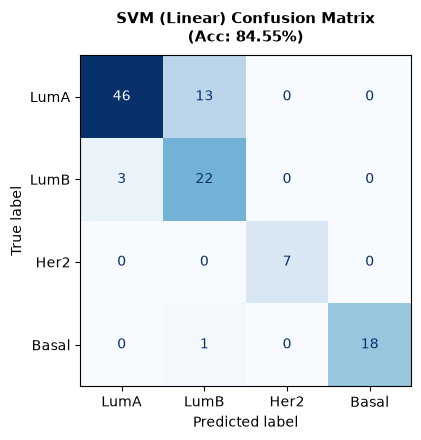


--- Random Forest Results ---
Accuracy:          87.27%  [95% CI: 80.91% - 93.64%]
Balanced Accuracy: 89.14%
Macro F1:          89.59%  [95% CI: 83.91% - 94.31%]
Weighted F1:       87.31%
              precision    recall  f1-score   support

        LumA       0.88      0.90      0.89        59
        LumB       0.72      0.72      0.72        25
        Her2       1.00      1.00      1.00         7
       Basal       1.00      0.95      0.97        19

    accuracy                           0.87       110
   macro avg       0.90      0.89      0.90       110
weighted avg       0.87      0.87      0.87       110



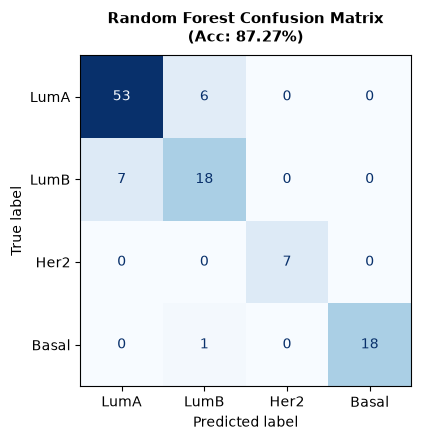


--- KNN (k=5) Results ---
Accuracy:          78.18%  [95% CI: 70.89% - 85.45%]
Balanced Accuracy: 85.17%
Macro F1:          81.36%  [95% CI: 72.40% - 88.24%]
Weighted F1:       79.22%
              precision    recall  f1-score   support

        LumA       0.91      0.71      0.80        59
        LumB       0.53      0.80      0.63        25
        Her2       0.78      1.00      0.88         7
       Basal       1.00      0.89      0.94        19

    accuracy                           0.78       110
   macro avg       0.80      0.85      0.81       110
weighted avg       0.83      0.78      0.79       110



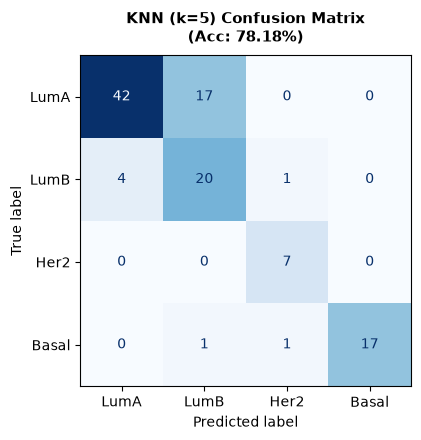

💾 Saved: ../outputs\Final_X_train.npz (+ .pkl)
💾 Saved: ../outputs\Final_X_test.npz (+ .pkl)
💾 Saved: ../outputs\Final_y_train.parquet (+ .pkl)
💾 Saved: ../outputs\Final_y_test.parquet (+ .pkl)
💾 Saved: ../outputs\Final_Feature_Names.pkl

🎉 MODELING & EVALUATION STEP COMPLETED SUCCESSFULLY!


In [8]:
print('='*70)
print('FINAL MODEL EVALUATION ON HELD-OUT TEST SET (N=110)')
print('(Test set evaluated strictly once at the end of the project)')
print('='*70)

X_train_bal, y_train_bal = smote.fit_resample(X_train_final, y_train_arr)
final_tuned = tune_models_grid_search(X_train_bal, y_train_bal, cv=3, random_state=42)
model_names = ['SVM (Linear)', 'Random Forest', 'KNN (k=5)']
target_names = ['LumA', 'LumB', 'Her2', 'Basal']
metrics_records = []

for name in model_names:
    clf = final_tuned[name]
    y_pred = clf.predict(X_test_final)
    
    acc = accuracy_score(y_test_arr, y_pred)
    bal_acc = balanced_accuracy_score(y_test_arr, y_pred)
    macro_f1 = f1_score(y_test_arr, y_pred, average='macro')
    weighted_f1 = f1_score(y_test_arr, y_pred, average='weighted')
    
    # 95% Bootstrap Confidence Intervals for small class robustness (Her2=7 samples)
    _, acc_lo, acc_hi = bootstrap_ci(y_test_arr, y_pred, metric_func=accuracy_score, n_bootstraps=1000, ci=95, random_state=42)
    _, f1_lo, f1_hi = bootstrap_ci(y_test_arr, y_pred, metric_func=lambda yt, yp: f1_score(yt, yp, average='macro'), n_bootstraps=1000, ci=95, random_state=42)
    
    print(f'\n--- {name} Results ---')
    print(f'Accuracy:          {acc*100:.2f}%  [95% CI: {acc_lo*100:.2f}% - {acc_hi*100:.2f}%]')
    print(f'Balanced Accuracy: {bal_acc*100:.2f}%')
    print(f'Macro F1:          {macro_f1*100:.2f}%  [95% CI: {f1_lo*100:.2f}% - {f1_hi*100:.2f}%]')
    print(f'Weighted F1:       {weighted_f1*100:.2f}%')
    print(classification_report(y_test_arr, y_pred, target_names=target_names))
    
    # Clean confusion matrix plot without empty figure bug
    clean_name = name.split()[0].lower()
    fig, ax = plot_confusion_matrix(y_test_arr, y_pred, target_names, f'{name} Confusion Matrix\n(Acc: {acc*100:.2f}%)')
    plt.show()

# Save final datasets
save_object(X_train_final, 'Final_X_train')
save_object(X_test_final, 'Final_X_test')
save_object(y_train, 'Final_y_train')
save_object(y_test, 'Final_y_test')
save_object(final_feature_names, 'Final_Feature_Names')
print('\n🎉 MODELING & EVALUATION STEP COMPLETED SUCCESSFULLY!')

## Biological Validation: Reactome Pathway & STRING PPI Analysis
Functional overrepresentation analysis of the selected biomarkers against Reactome pathways (with measured gene background universe and FDR < 0.05 enforcement) and STRING PPI interactome validation.
Note: Because PAM50 subtypes are canonically defined by key ER/HER2 axis genes, enrichment of estrogen and cell cycle signaling pathways is expected and confirms consistency with canonical PAM50 biology rather than serving as an independent discovery.

In [9]:
print('Running Biological Pathway Enrichment Analysis via Reactome & STRING...')
print('Note: PAM50 subtypes are canonically defined by key ER/HER2 axis genes.')
print('Enrichment of estrogen and cell cycle pathways confirms consistency with PAM50 biology.')

rna_p = pd.read_csv('../outputs/results/pathway_enrichment_reactome_rna.csv') if os.path.exists('../outputs/results/pathway_enrichment_reactome_rna.csv') else pd.DataFrame()
if not rna_p.empty:
    print(f'\nTop Enriched Reactome Pathways for RNA Biomarkers (FDR < 0.05, {len(rna_p)} pathways):')
    for _, row in rna_p.head(6).iterrows():
        print(f"  - [{row['Pathway_ID']}] {row['Pathway_Name']} (FDR={row['FDR']:.2e}, Found={row['Entities_Found']}/{row['Entities_Total']})")

string_file = '../outputs/results/ppi_network_summary_rna.json'
if os.path.exists(string_file):
    with open(string_file, 'r') as f:
        s_info = json.load(f)
    print(f"\nSTRING Interactome PPI Enrichment (RNA Biomarkers):")
    print(f"  - Nodes: {s_info.get('number_of_nodes', 'N/A')}, Edges: {s_info.get('number_of_edges', 'N/A')} (Expected: {s_info.get('expected_number_of_edges', 'N/A')})")
    print(f"  - PPI Enrichment p-value: {s_info.get('p_value', 0):.2e}")

Running Biological Pathway Enrichment Analysis via Reactome & STRING...
Note: PAM50 subtypes are canonically defined by key ER/HER2 axis genes.
Enrichment of estrogen and cell cycle pathways confirms consistency with PAM50 biology.

Top Enriched Reactome Pathways for RNA Biomarkers (FDR < 0.05, 20 pathways):
  - [R-HSA-8939211] ESR-mediated signaling (FDR=3.91e-08, Found=11/257)
  - [R-HSA-9018519] Estrogen-dependent gene expression (FDR=6.72e-08, Found=9/153)
  - [R-HSA-9006931] Signaling by Nuclear Receptors (FDR=8.05e-07, Found=11/383)
  - [R-HSA-9924644] Developmental Lineages of the Mammary Gland (FDR=2.12e-04, Found=5/81)
  - [R-HSA-9734779] Developmental Cell Lineages of the Integumentary System (FDR=1.19e-03, Found=5/122)
  - [R-HSA-9927426] Developmental Lineage of Mammary Gland Alveolar Cells (FDR=8.16e-03, Found=3/41)

STRING Interactome PPI Enrichment (RNA Biomarkers):
  - Nodes: 31, Edges: 38 (Expected: 7)
  - PPI Enrichment p-value: 3.33e-16
